# Setting

In [8]:
import pandas as pd
from datetime import datetime

# 買進賣出需要的手續費
fee = {
    "tax_stock": 0.003,  # 買進與賣出各0.003
    "tax_future": 0.00002 * 2,  # 買進與賣出各0.00002
    "fee_stock": 0.001425 * 2,  # 券商手續費公道價，買進與賣出各0.001425
    "fee_future": 0.00002 * 2,  # 各家不大相同，以交易稅計算
    "sliding_price": 0.00001,  # 滑價
}

# 股票清單
data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    ["2207", "和泰車", "tw"],
    ["2881", "富邦金", "tw"],
    ["2412", "中華電", "tw"],
    ["3045", "台灣大", "tw"],
    
    # ["6505", "台塑化", "tw"],
    # ["2408", "南亞科", "tw"],
    # ["2603", "長榮", "tw"],
    # ["6214", "精誠", "tw"],
    # ["2379", "瑞昱", "tw"],
    # ["3661", "世芯", "tw"],
    # ["2357", "華碩", "tw"],
    # ["2345", "智邦", "tw"],  # 17
    
    
    # ["AAPL", "Apple Inc.", "us"],
    # ["MSFT", "Microsoft", "us"],
    # ["TSLA", "Tesla", "us"],
    # ["NVDA", "Nvidia", "us"],
    # ["AMZN", "Amazon inc.", "us"],
    # ["GOOGL", "Google", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BA", "Boeing", "us"],
    # ["MRNA", "Moderna", "us"],
    
    # ["BRK", "Berkshire Hathaway", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    # ["WMT", "Walmart", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["DIS", "Disney", "us"],
    # ["BAC", "Bank of America", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["PYPL", "PayPal", "us"],
    # ["ADBE", "Adobe", "us"],  # 18
]

# 指數
index_twii = [
    ["2308", "台達電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2330", "台積電", "tw"],
    ["2382", "廣達", "tw"],
    ["2412", "中華電", "tw"],
    ["2454", "聯發科", "tw"],
    ["2881", "富邦金", "tw"],
    ["2882", "國泰金", "tw"],
    ["2891", "中信金", "tw"],
    ["6505", "台塑化", "tw"],
]

index_spx = [
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["Nvidia", "NVDA", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["META", "Meta Platforms", "us"],
    ["GOOGL", "Google", "us"],
    ["TSLA", "Tesla", "us"],
    ["AVGO", "Broadcom", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
]

market_index = [
    ["twii", "台灣指數期貨", "tw", index_twii],
    ["spx", "S&P 500", "us", index_spx],
]

date_ranges = [
    ["20230401", "20240331", "2024Q1"],
    ["20230701", "20240630", "2024Q2"],
    ["20231001", "20240930", "2024Q3"],
    ["20240101", "20241231", "2024Q4"],
    # ["20231001", "20240131", "2024M1"],
    # ["20231101", "20240229", "2024M2"],
    # ["20231201", "20240331", "2024M3"],
    # ["20240101", "20240430", "2024M4"],
    # ["20240201", "20240531", "2024M5"],
    # ["20240301", "20240630", "2024M6"],
    # ["20240401", "20240731", "2024M7"],
    # ["20240501", "20240831", "2024M8"],
    # ["20240601", "20240930", "2024M9"],
    # ["20240701", "20241031", "2024M10"],
    # ["20240801", "20241130", "2024M11"],
    # ["20240901", "20241231", "2024M12"],
]

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }

# On(Over Night)抱股過夜作法，正面就持續持有，負面就賣出
# Usable Factor 只跑有用的factor

In [9]:
def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

In [10]:
import matplotlib.pyplot as plt
from math import ceil, sqrt

def display_all_plots(all_plots):
    # 計算需要的子圖行數與列數（接近正方形排列）
    num_plots = len(all_plots)
    cols = ceil(sqrt(num_plots))  # 列數
    rows = ceil(num_plots / cols)  # 行數

    # 創建一個大的畫布
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    # fig.suptitle("Trading Results for All Stocks", fontsize=16, y=0.95)

    # 確保 axes 是一個 2D 陣列
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1 or cols == 1:
        axes = [axes] if rows == 1 else [[ax] for ax in axes]
    else:
        axes = axes.reshape(rows, cols)

    # 在每個子圖中顯示單獨的圖表
    for idx, single_fig in enumerate(all_plots):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        
        # 從單個圖表中提取並繪製數據
        for line in single_fig.axes[0].get_lines():
            ax.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
        
        # 設定標題、標籤與圖例
        ax.set_title(single_fig.axes[0].get_title())
        ax.set_xlabel(single_fig.axes[0].get_xlabel())
        ax.set_ylabel(single_fig.axes[0].get_ylabel())
        ax.legend()

    # 移除多餘的空白子圖
    for idx in range(num_plots, rows * cols):
        row, col = divmod(idx, cols)
        fig.delaxes(axes[row][col])

    # 調整整體佈局
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # 調整總標題的位置
    plt.show()

In [11]:
def cacl_avg(df_stocks_results, wincount=None, ttl_count=None):
    '''
        only return average row
    '''
    
    average_row = pd.DataFrame()
    average_row['tp'] = [df_stocks_results['tp'].sum()]
    average_row['fp'] = [df_stocks_results['fp'].sum()]
    average_row['tn'] = [df_stocks_results['tn'].sum()]
    average_row['fn'] = [df_stocks_results['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_stocks_results['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum()]
    average_row['ev'] = (df_stocks_results['ev'].astype(float) * df_stocks_results['avail_count']).sum() / df_stocks_results['avail_count'].sum()
    average_row['precision_ev'] = (df_stocks_results['precision_ev'].astype(float) * (df_stocks_results['tp'] + df_stocks_results['fp'])).sum() / (df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum())
    if ttl_count is None:
        average_row['win B&H'] = None
    else:
        average_row['win B&H'] = round(wincount / ttl_count, 2)
    
    return average_row

In [12]:
# from factor_overnight import FactorON
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#         "run_count": "1"
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = FactorON(env)
#     eval_module.show_individual(mode=1)
    

In [13]:
# from factor_overnight import FactorON
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#         "run_count": "1"
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = FactorON(env)
#     a = eval_module.show_sig()
    
#     print(eval_module.get_individual(mode=1))
    

# Factor Daytrade

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4
BA Boeing us 2024Q1
BA Boeing us 2024Q2
BA Boeing us 2024Q3
BA Boeing us 2024Q4
MRNA Moderna us 2024Q1
MRNA Moderna us 2024Q2
MRNA Moderna us 2024Q3
MRNA Moderna us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
AAPL - 2024Q1,0.475410,0.433333,-0.000280,0.000042,61,13,17,16,15
AAPL - 2024Q2,0.492063,0.452381,-0.001358,-0.000913,63,19,23,12,9
AAPL - 2024Q3,0.546875,0.615385,-0.000777,0.000695,64,24,15,11,14
AAPL - 2024Q4,0.562500,0.666667,0.001328,0.002856,64,30,15,6,13
MSFT - 2024Q1,0.475410,0.489362,-0.001215,-0.000369,61,23,24,6,8
MSFT - 2024Q2,0.587302,0.630435,-0.000429,-0.000260,63,29,17,8,9
MSFT - 2024Q3,0.484375,0.472222,0.000076,-0.001241,64,17,19,14,14
MSFT - 2024Q4,0.546875,0.585366,0.000769,0.000862,64,24,17,11,12
TSLA - 2024Q1,0.540984,0.454545,0.002148,0.001646,61,5,6,28,22
TSLA - 2024Q2,0.476190,0.200000,-0.002559,-0.008943,63,1,4,29,29


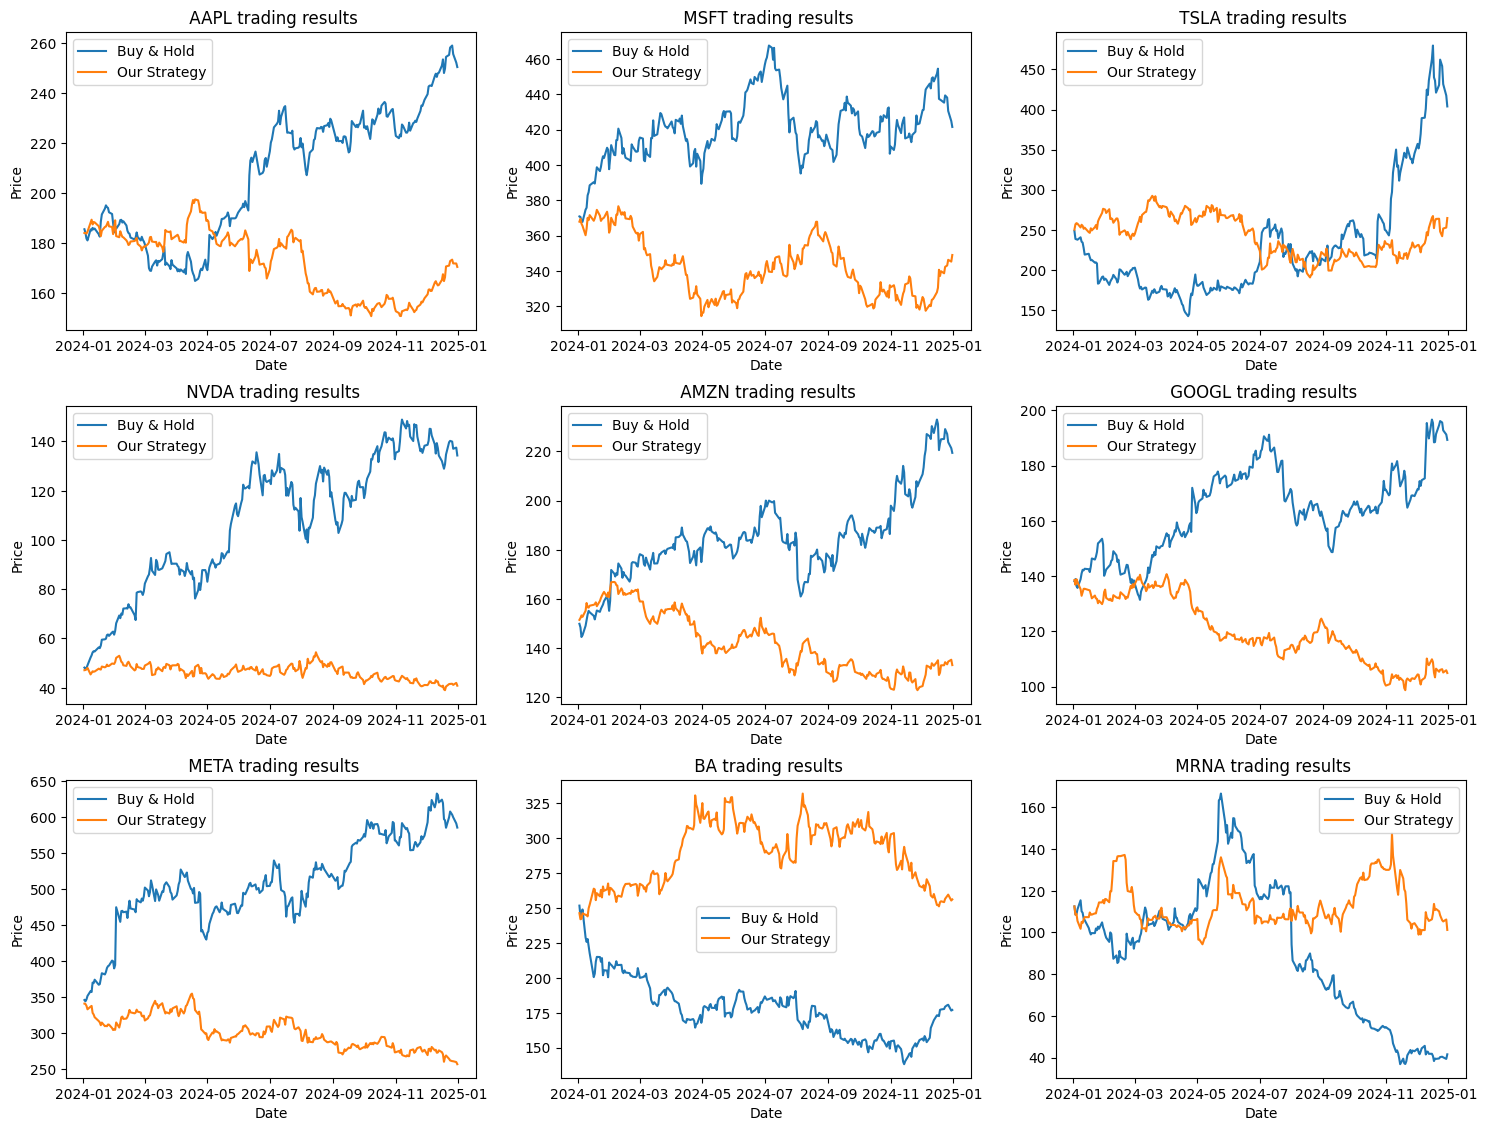

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.498884,0.508757,-0.000267,-0.000358,0.22
總和,0.498884,0.508757,-0.000267,-0.000358,0.22


In [5]:
from factor import Factor

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Factor(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# Factor OverNight

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4
BA Boeing us 2024Q1
BA Boeing us 2024Q2
BA Boeing us 2024Q3
BA Boeing us 2024Q4
MRNA Moderna us 2024Q1
MRNA Moderna us 2024Q2
MRNA Moderna us 2024Q3
MRNA Moderna us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
AAPL - 2024Q1,0.555556,0.416667,-0.000966,-0.003967,18,5,7,5,1
AAPL - 2024Q2,0.588235,0.666667,0.001528,0.012201,17,6,3,4,4
AAPL - 2024Q3,0.533333,0.666667,-0.006409,0.000699,15,6,3,2,4
AAPL - 2024Q4,0.444444,0.545455,-0.003451,-0.001172,18,6,5,2,5
MSFT - 2024Q1,0.500000,0.555556,0.006872,0.008139,10,5,4,0,1
MSFT - 2024Q2,0.538462,0.500000,0.000824,0.000811,13,4,4,3,2
MSFT - 2024Q3,0.444444,0.500000,0.003506,0.001653,18,5,5,3,5
MSFT - 2024Q4,0.090909,0.000000,-0.008447,0.000000,11,0,6,1,4
TSLA - 2024Q1,0.666667,0.333333,0.003310,-0.022825,12,1,2,7,2
TSLA - 2024Q2,0.000000,0.000000,0.000000,0.000000,4,0,2,0,2


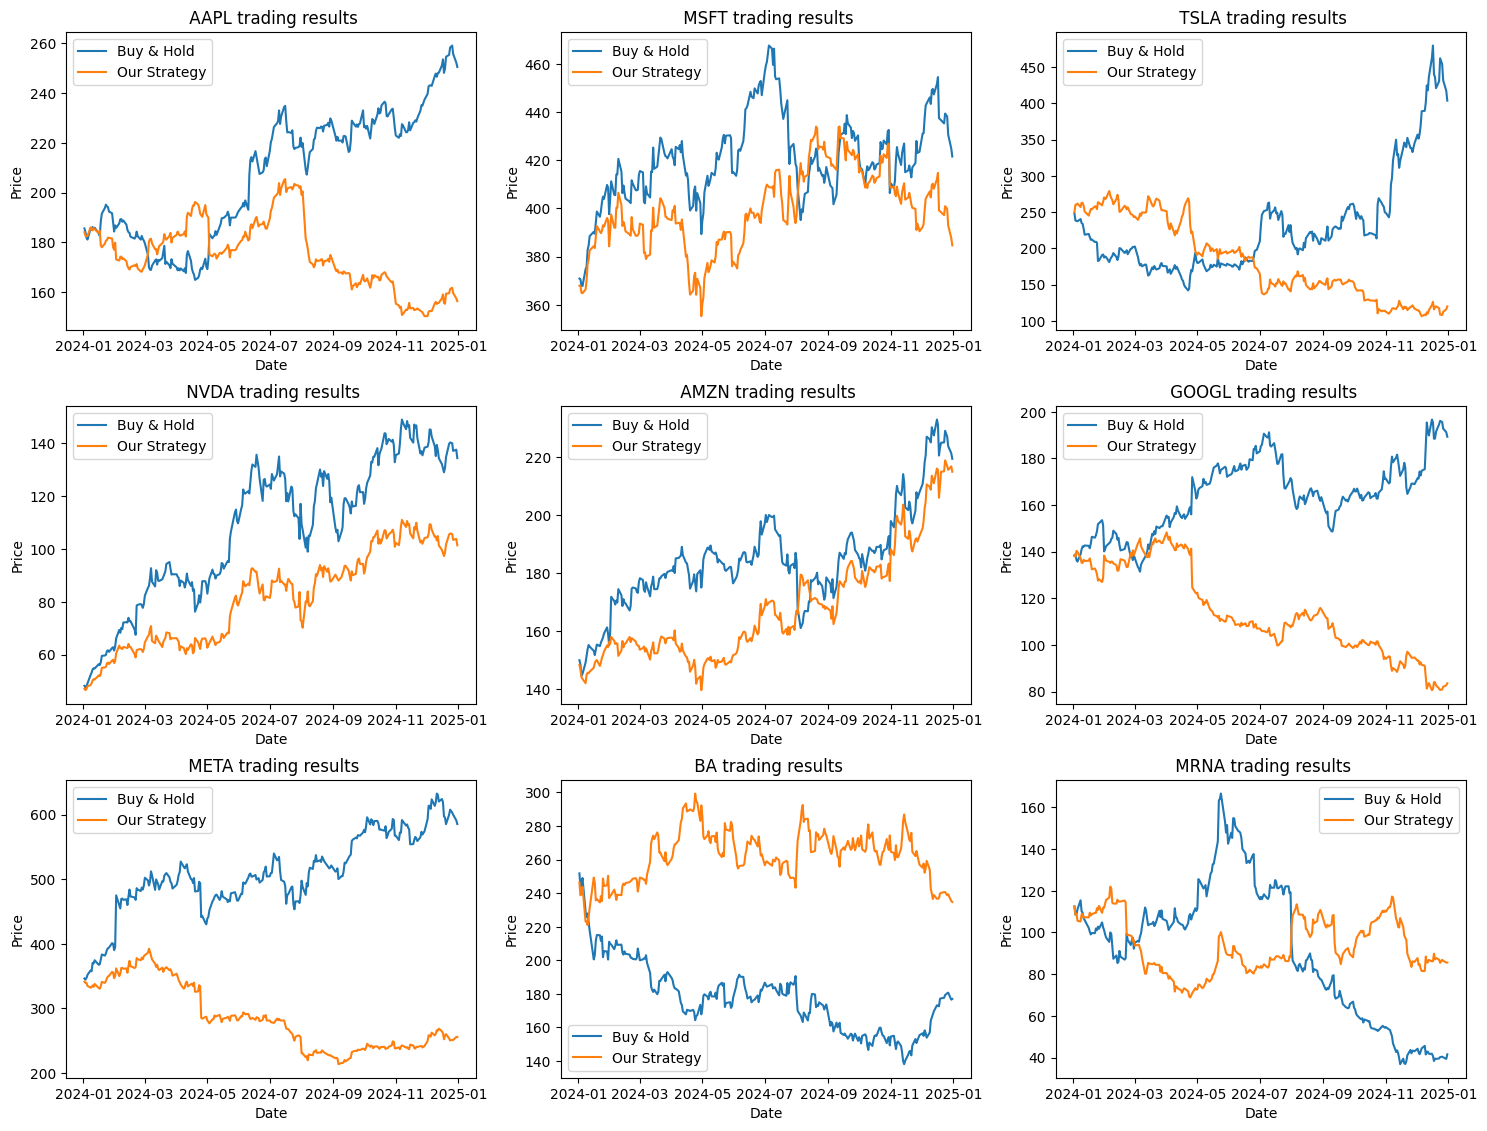

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.476954,0.496296,0.000264,0.003965,0.22
總和,0.476954,0.496296,0.000264,0.003965,0.22


In [6]:
from factor_overnight import FactorON

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = FactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # print(df['test'])
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# EMBD OverNight (under construct)

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4


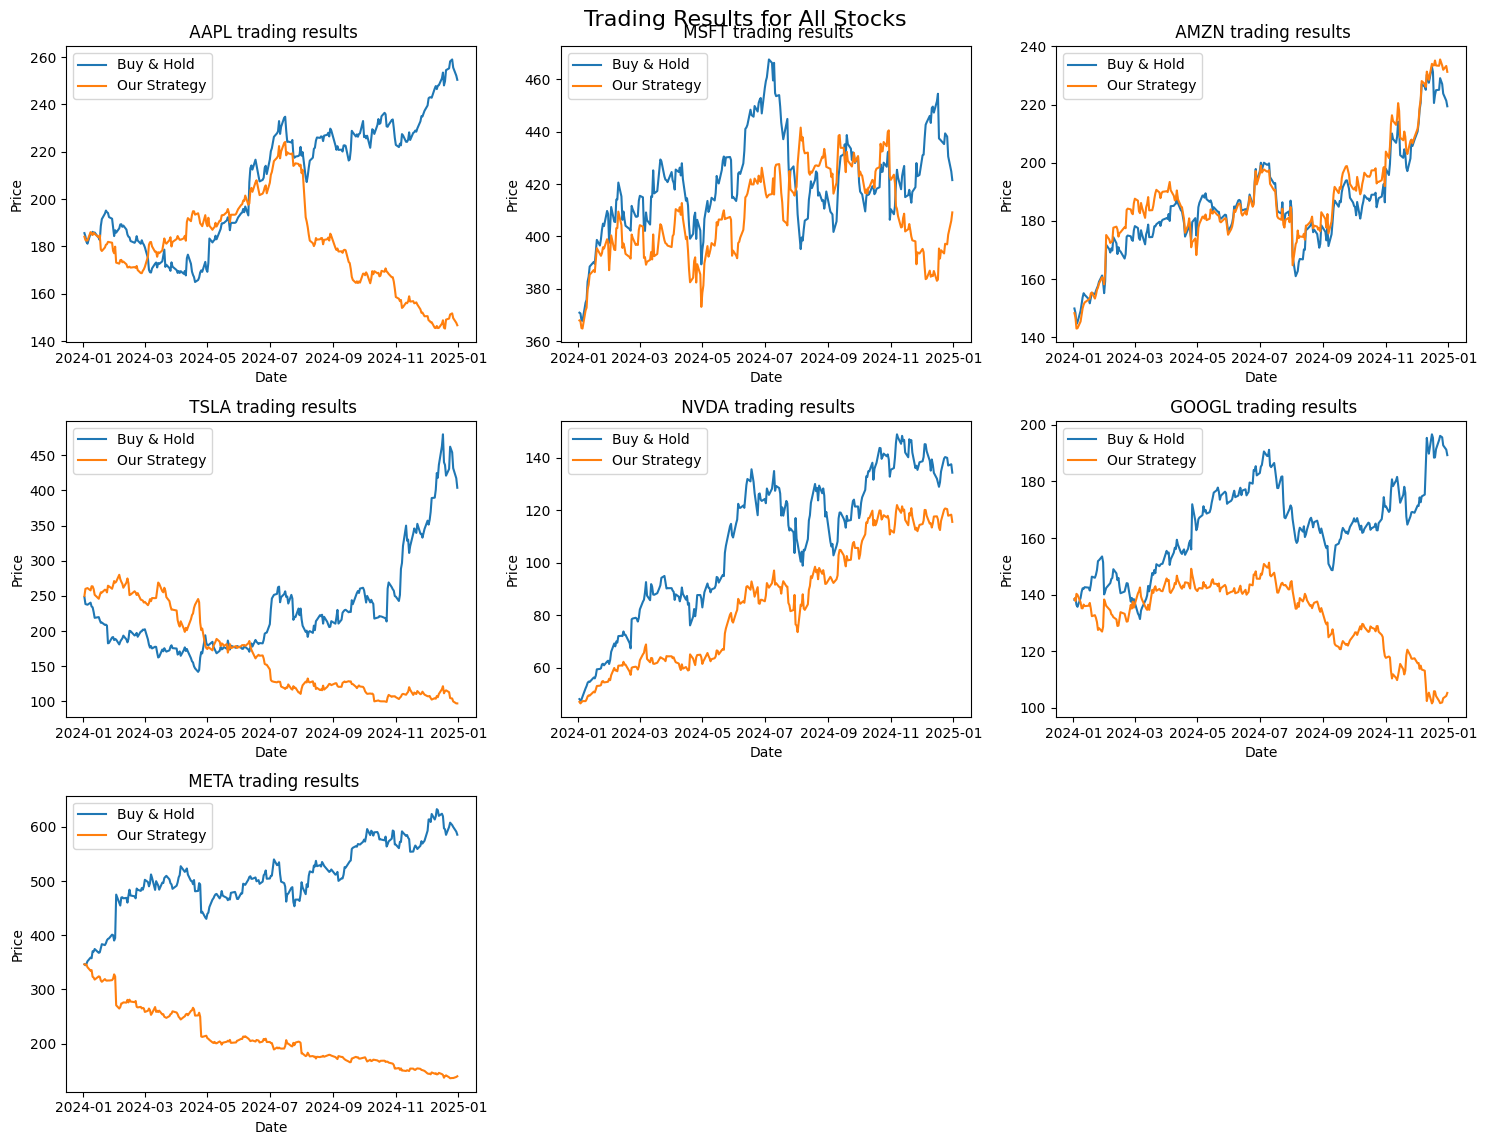

,tp,fp,tn,fn,accuracy,precision,ev,precision_ev,win B&H
平均值1,104.0,99.0,77.0,94.0,0.483957,0.512315,0.000742,0.006764,0.14
最終平均值,104.0,99.0,77.0,94.0,0.483957,0.512315,0.000742,0.006764,0.14


In [26]:
from factor_embd import FactorEmbdON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = FactorEmbdON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            mode = 1    # 0:acc 1:ev
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            
            # plot fig
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
        
        # # show stock results
        # stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        # stock_avg.index = [stock[0]]
        # display(stock_avg.loc[:, selected_columns])
        
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# MA

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4


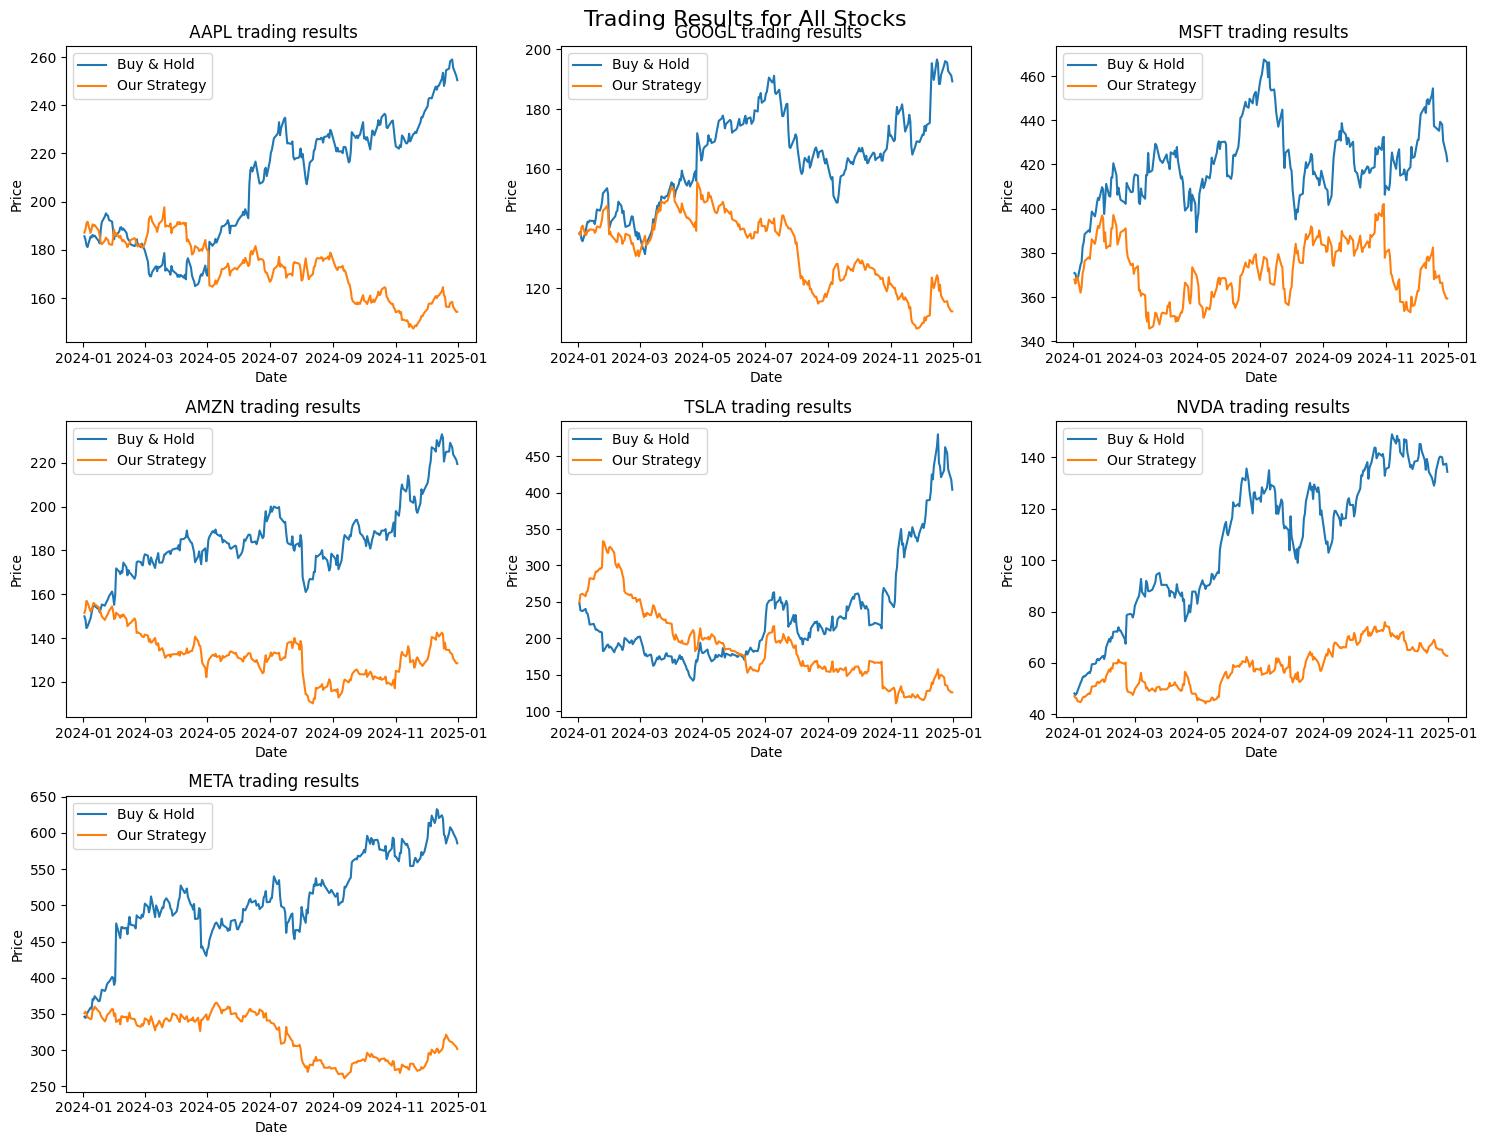

,tp,fp,tn,fn,accuracy,precision,ev,precision_ev,win B&H
平均值1,96.0,104.0,53.0,117.0,0.402703,0.48,-0.001578,0.007119,0.0
最終平均值,96.0,104.0,53.0,117.0,0.402703,0.48,-0.001578,0.007119,0.0


In [12]:
from movment import Movement
from api import eval_onlymov

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "MOV" : "MA5"
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Movement(env)

            df = eval_module.run_movment(eval_onlymov)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result()
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['平均值' + str(i)])

    # Sum the tp, fp, tn, fn columns
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    average_row['ev'] = df_selected['ev'].replace('%', '', regex=True).astype(float).mean()
    average_row['precision_ev'] = df_selected['precision_ev'].replace('%', '', regex=True).astype(float).mean()
    average_row['win B&H'] = round(wincount / ttl_count, 2)

    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")

    # display(df_selected_with_avg)
    return avgs

for i in range(1, 2):
    print(i)
    avgs = runAll(i, avgs)

# 呼叫函數來顯示整合的大圖
display_all_plots(all_plots)

# display(avgs)
# 計算最後一列的平均值
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['最終平均值']

# 將最終平均值添加到 avgs
avgs = pd.concat([avgs, final_average_row])

display(avgs)

# 7-2 Stock - Factor Usable

1
2330 台積電 tw 2024Q1
2330 台積電 tw 2024Q2
2330 台積電 tw 2024Q3
2330 台積電 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2330,0.586957,0.689655,0.0162,0.026177,46,20,9,7,10,yes


2317 鴻海 tw 2024Q1
2317 鴻海 tw 2024Q2
2317 鴻海 tw 2024Q3
2317 鴻海 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2317,0.514286,0.56,0.023344,0.034851,35,14,11,4,6,yes


2454 聯發科 tw 2024Q1
2454 聯發科 tw 2024Q2
2454 聯發科 tw 2024Q3
2454 聯發科 tw 2024Q4


...

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2881,0.444444,0.444444,0.012903,0.016541,36,12,15,4,5,yes


2412 中華電 tw 2024Q1
2412 中華電 tw 2024Q2
2412 中華電 tw 2024Q3
2412 中華電 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2412,0.411765,0.392857,0.000011,-1.790722e-07,34,11,17,3,3,no


3045 台灣大 tw 2024Q1
3045 台灣大 tw 2024Q2
3045 台灣大 tw 2024Q3
3045 台灣大 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
3045,0.530612,0.533333,0.002015,0.0035,49,16,14,10,9,no


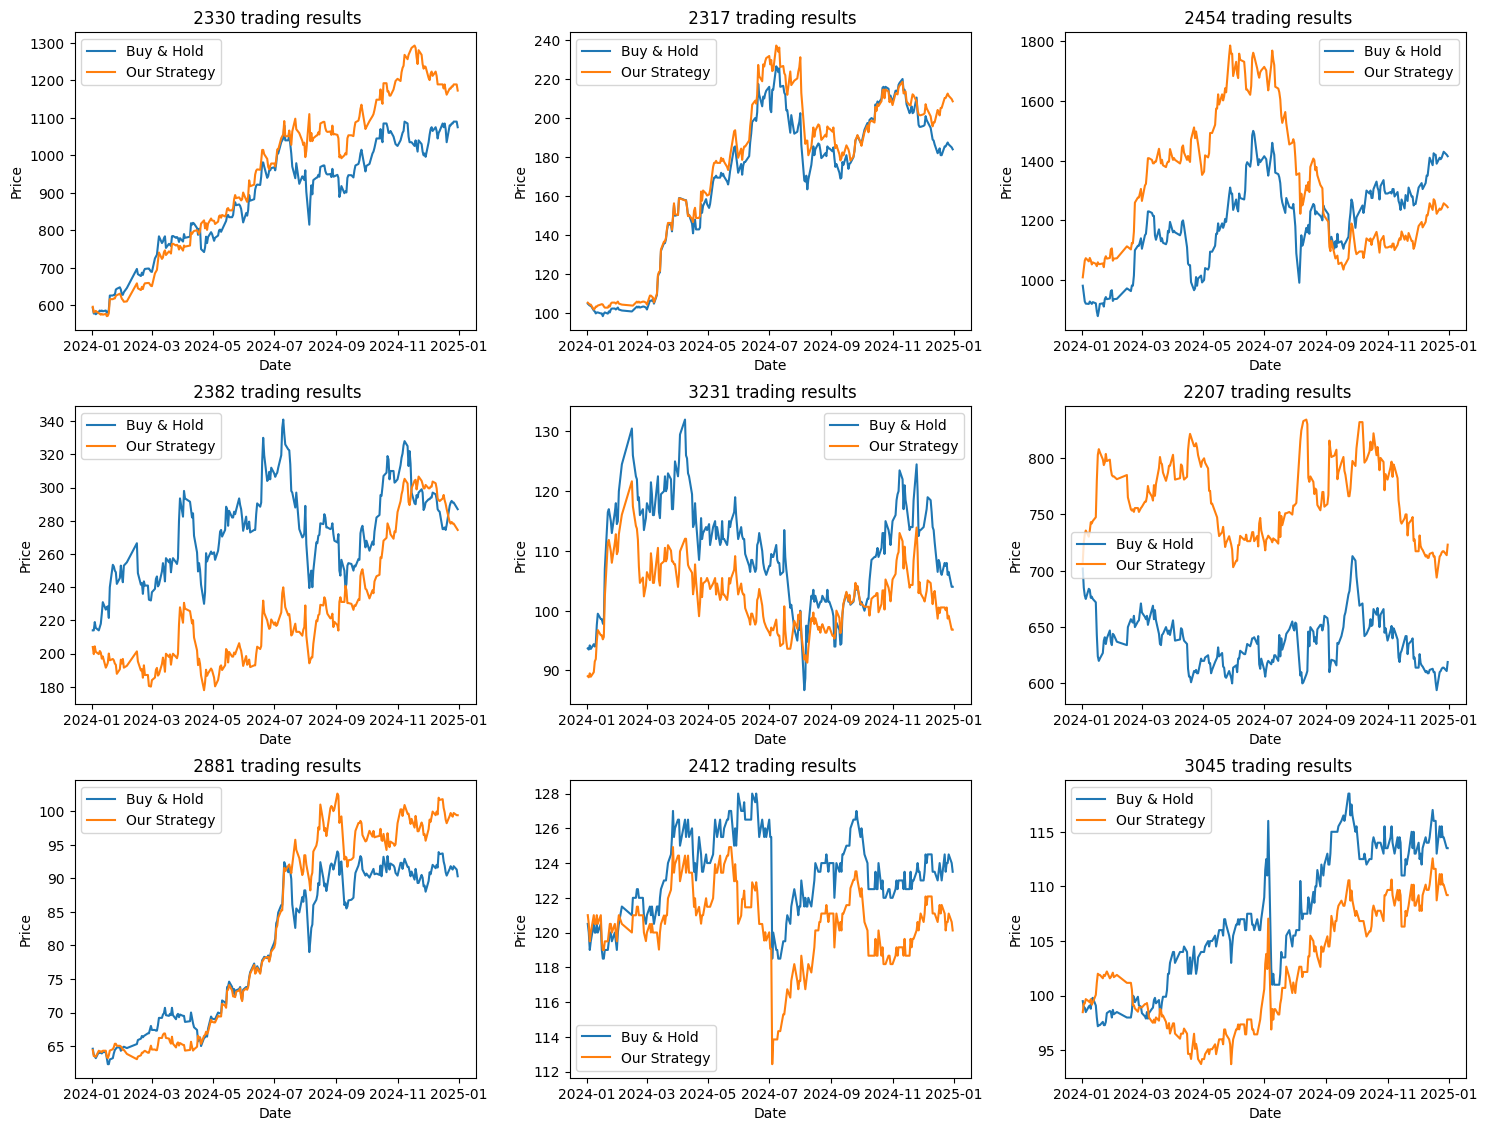

,accuracy,precision,ev,precision_ev,win B&H
第1次,47.20%,49.17%,0.007802,0.012779,0.44
總和,47.20%,49.17%,0.007802,0.012779,0.44


In [14]:
## V1
from usable_on import UsableFactorON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2 Index - Factor Usable 

In [7]:
## V1
from usable_on_index import Index_UsableFactorON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Index_UsableFactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

1
twii 台灣指數期貨 tw 2024Q1
Generating factors for twii
Processing for date 20230406	20230405 news found


KeyboardInterrupt: 

# 7-2-1 Factor Usable + eval only long

1
AAPL Apple Inc. us 2024Q1
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q2
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q3
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q4
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q1
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q2
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q3
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q4
Start Running Genetic Algorithm
TSLA Tesla us 2024Q1
Start Running Genetic Algorithm
TSLA Tesla us 2024Q2
Start Running Genetic Algorithm
TSLA Tesla us 2024Q3
Start Running Genetic Algorithm
TSLA Tesla us 2024Q4
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q1
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q2
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q3
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q4
Start Running Genetic Algorithm
AMZN Amazon inc. us 2024Q1
Start Running Genetic Algorithm
AMZN Amazon inc. us 2024Q2
Start Running Genetic Al

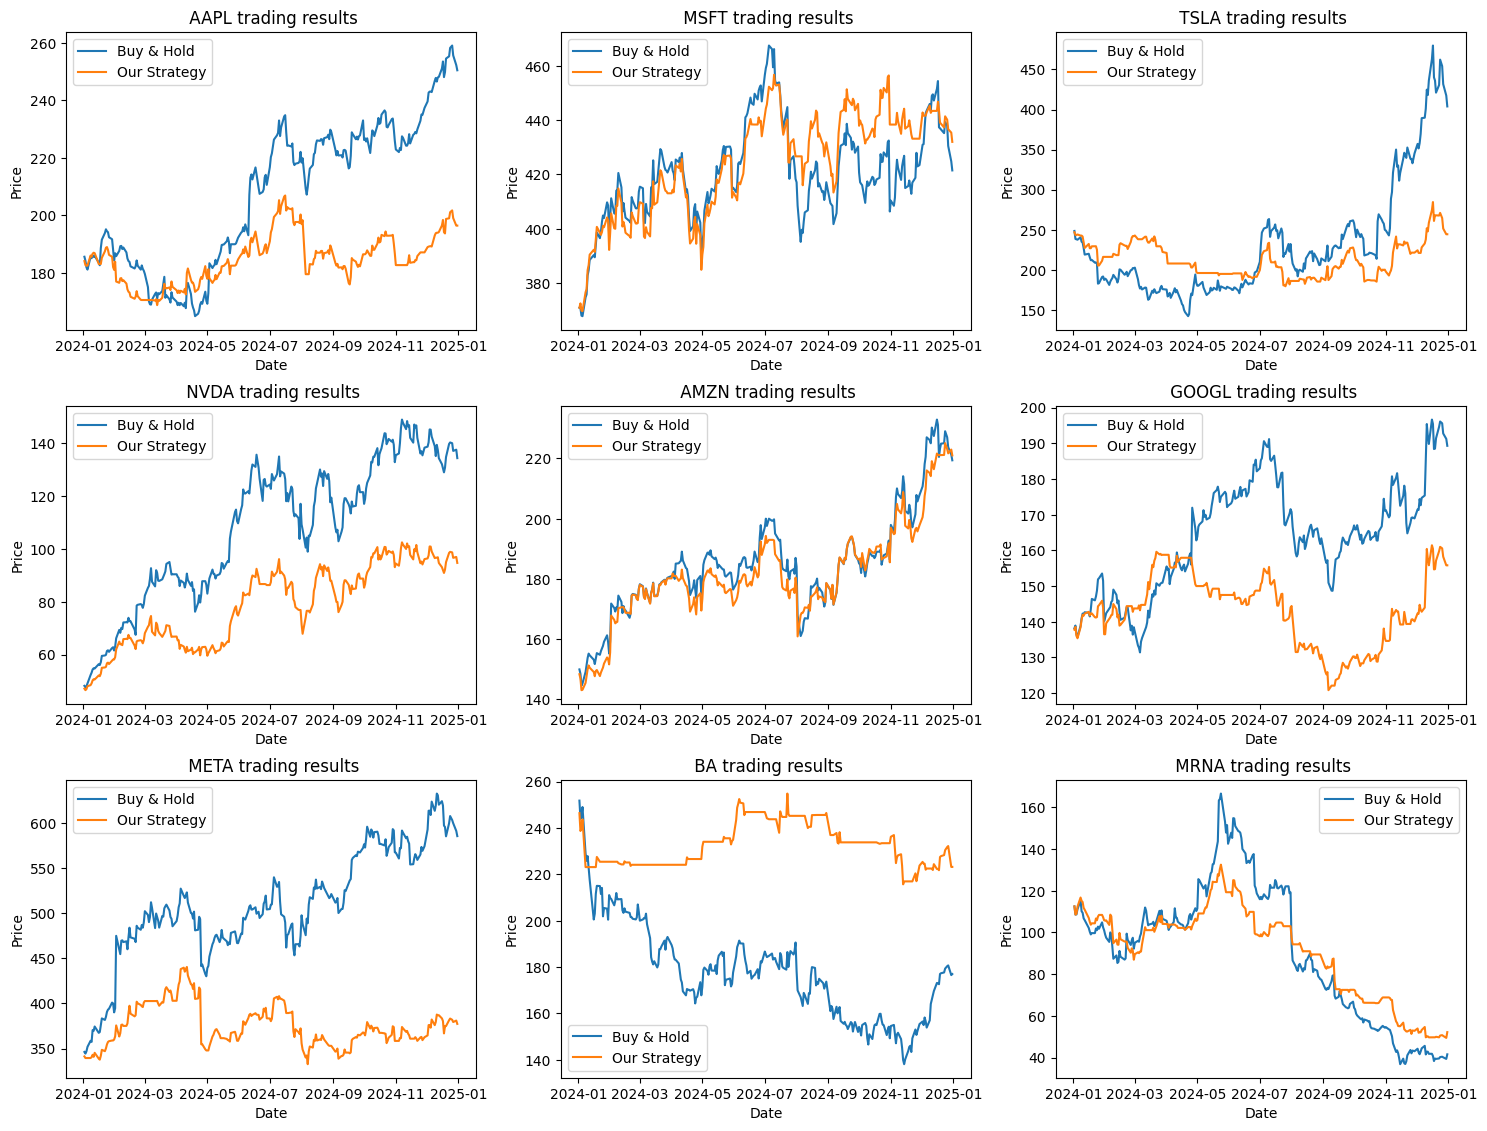

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.497222,0.497222,0.002933,0.002933,0.44
總和,0.497222,0.497222,0.002933,0.002933,0.44


In [5]:
from usable_on_long import UsableFactorONLong

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorONLong(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            # print(stock_results)

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    # display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2-2 Factor Usable + eval only short

1
AAPL Apple Inc. us 2024Q1
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q2
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q3
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q4
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q1
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q2
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q3
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q4
Start Running Genetic Algorithm
TSLA Tesla us 2024Q1
Start Running Genetic Algorithm
TSLA Tesla us 2024Q2
Start Running Genetic Algorithm
TSLA Tesla us 2024Q3
Start Running Genetic Algorithm
TSLA Tesla us 2024Q4
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q1
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q2
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q3
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q4
Start Running Genetic Algorithm
AMZN Amazon inc. us 2024Q1
Start Running Genetic Algorithm
AMZN Amazon inc. us 2024Q2
Start Running Genetic Al

/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_2341/2480614451.py:79: RuntimeWarning: invalid value encountered in scalar divide
  average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())


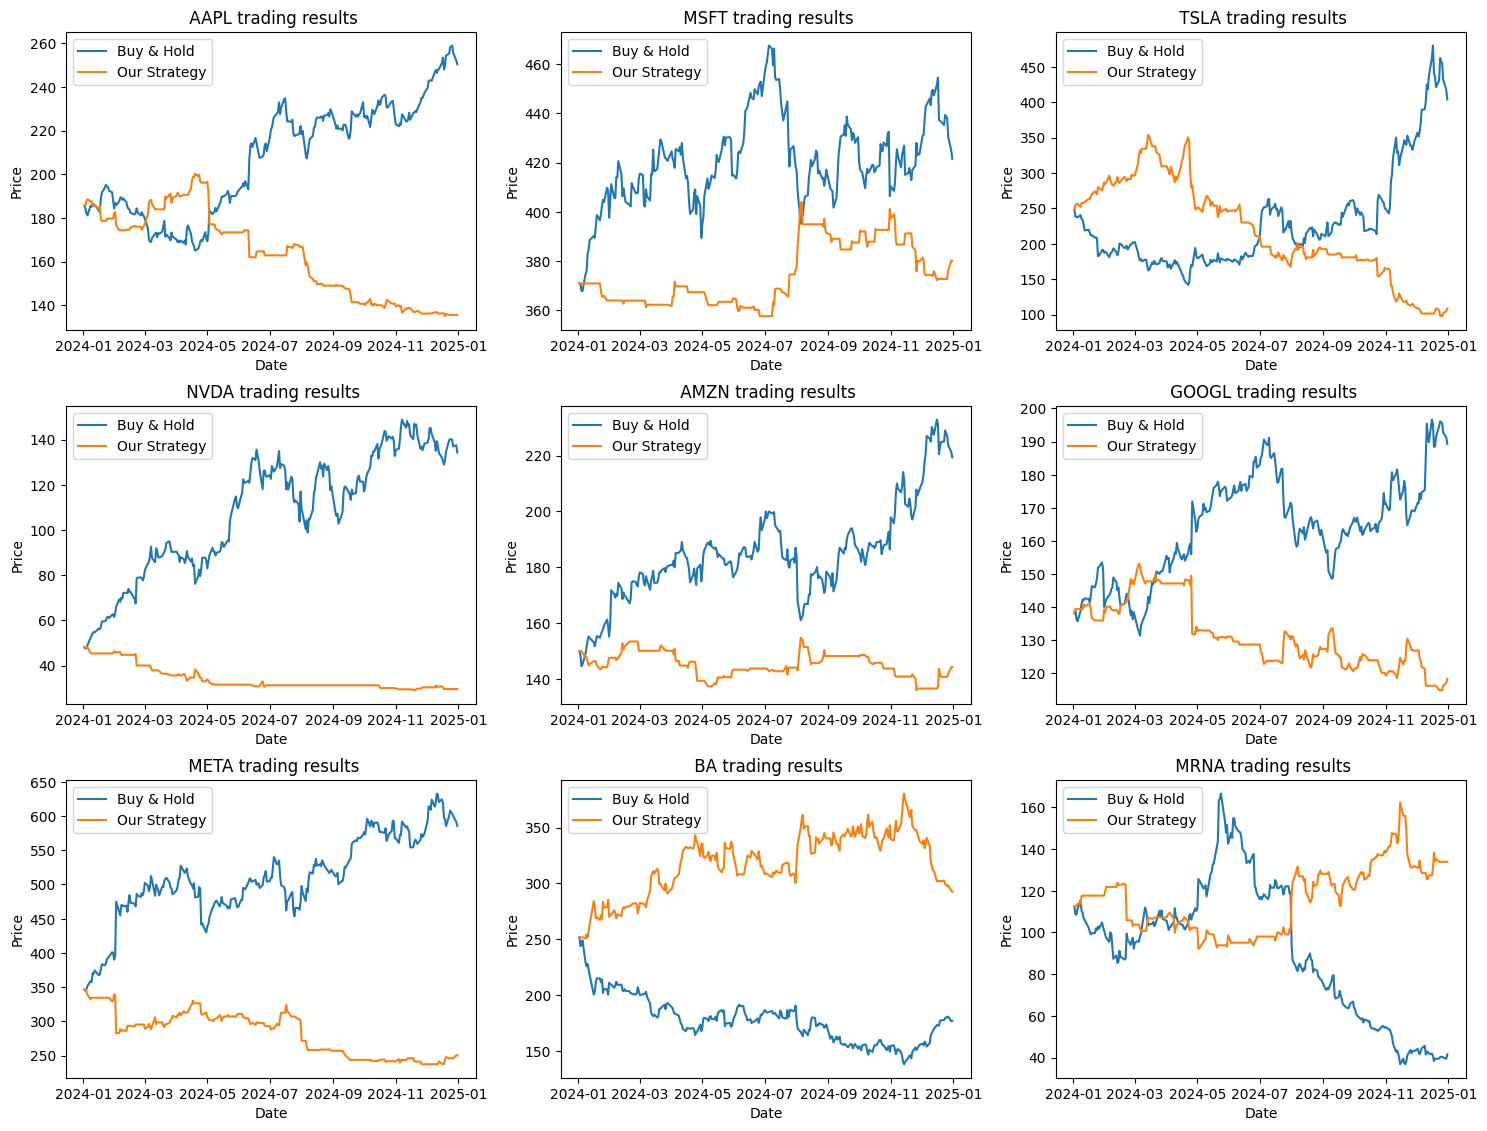

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.479675,NaN,-0.004339,NaN,0.22
總和,0.479675,NaN,-0.004339,NaN,0.22


In [6]:
from usable_on_short import UsableFactorONShort

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorONShort(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            # print(stock_results)

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    # display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-3 Factor Usable + MA

1
2330 台積電 tw 2024Q1
2330 台積電 tw 2024Q2
2330 台積電 tw 2024Q3
2330 台積電 tw 2024Q4
2317 鴻海 tw 2024Q1
2317 鴻海 tw 2024Q2
2317 鴻海 tw 2024Q3
2317 鴻海 tw 2024Q4
2454 聯發科 tw 2024Q1
2454 聯發科 tw 2024Q2
2454 聯發科 tw 2024Q3
2454 聯發科 tw 2024Q4
2382 廣達 tw 2024Q1
2382 廣達 tw 2024Q2
2382 廣達 tw 2024Q3
2382 廣達 tw 2024Q4
3231 緯創 tw 2024Q1
3231 緯創 tw 2024Q2
3231 緯創 tw 2024Q3
3231 緯創 tw 2024Q4
2207 和泰車 tw 2024Q1
2207 和泰車 tw 2024Q2
2207 和泰車 tw 2024Q3
2207 和泰車 tw 2024Q4
2881 富邦金 tw 2024Q1
2881 富邦金 tw 2024Q2
2881 富邦金 tw 2024Q3
2881 富邦金 tw 2024Q4
2412 中華電 tw 2024Q1
2412 中華電 tw 2024Q2
2412 中華電 tw 2024Q3
2412 中華電 tw 2024Q4
3045 台灣大 tw 2024Q1
3045 台灣大 tw 2024Q2
3045 台灣大 tw 2024Q3
3045 台灣大 tw 2024Q4


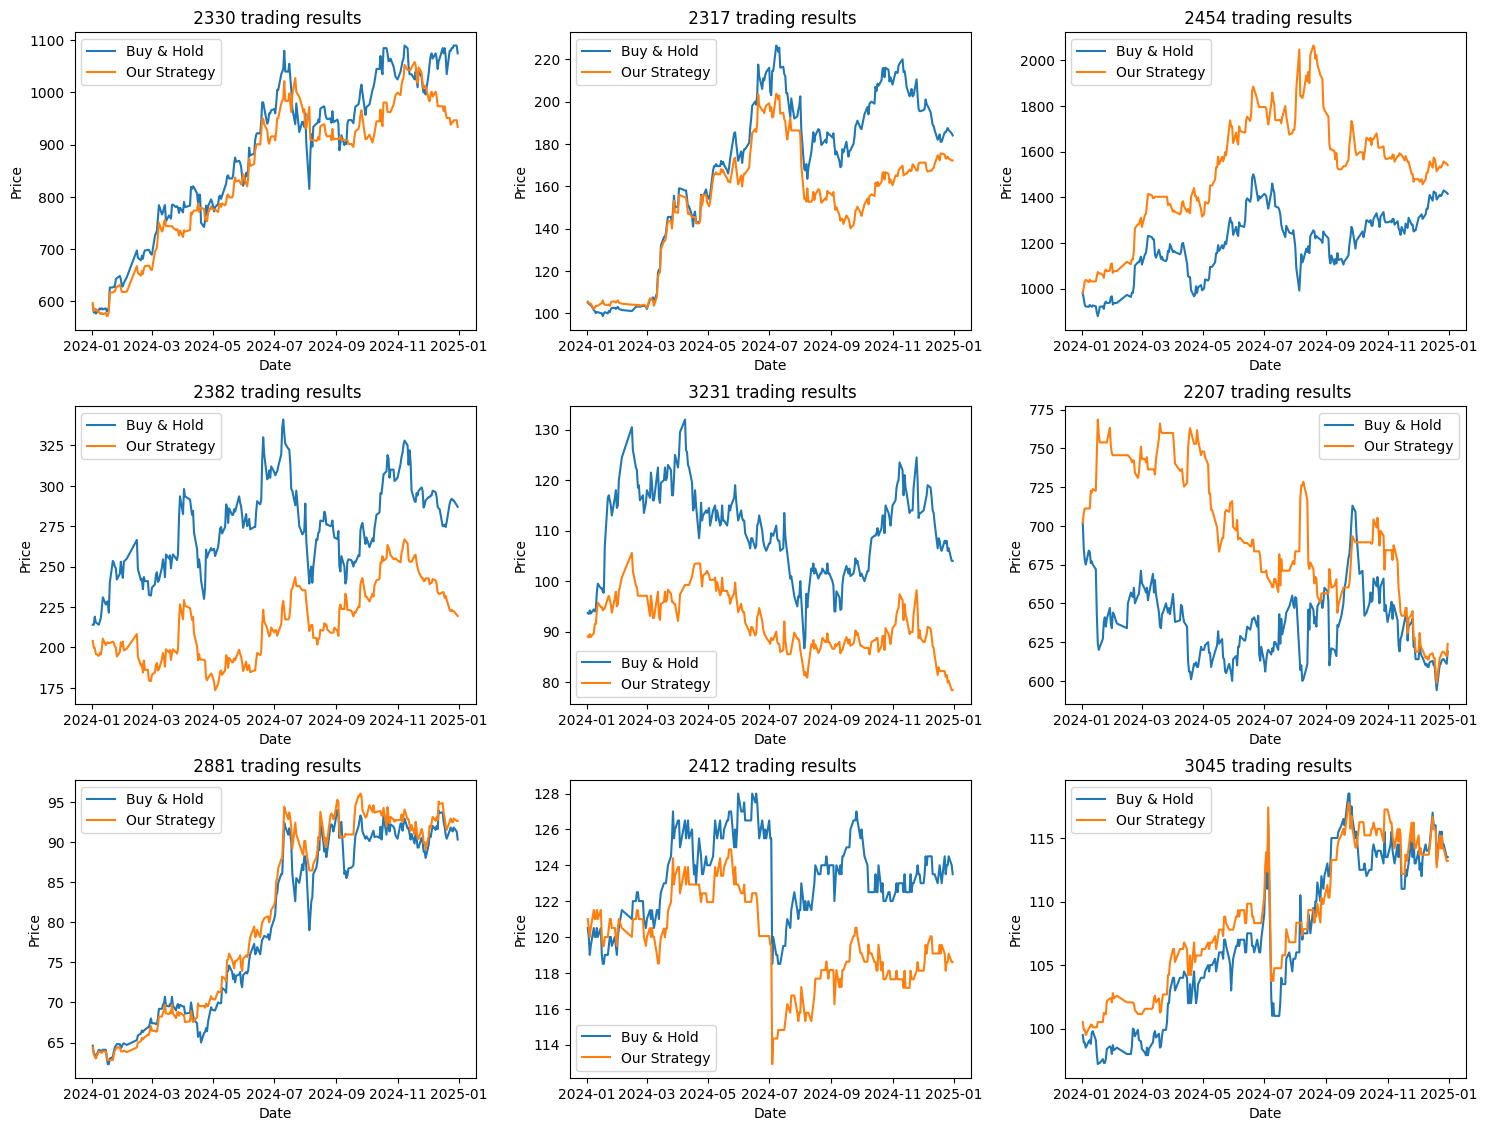

,accuracy,precision,ev,precision_ev,win B&H
第1次,45.14%,47.00%,0.006199,0.007154,0.33
總和,45.14%,47.00%,0.006199,0.007154,0.33


In [16]:
from usable_movement import UsableMovment

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "MOV": "EMA5",
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableMovment(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # # show stock results
        # stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        # stock_avg.index = [stock[0]]
        # display(stock_avg.loc[:, selected_columns])
        
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-4 Factor Usable Reason

1
2330 台積電 tw 2024Q1
2330 台積電 tw 2024Q2
2330 台積電 tw 2024Q3
2330 台積電 tw 2024Q4
2317 鴻海 tw 2024Q1
2317 鴻海 tw 2024Q2
2317 鴻海 tw 2024Q3
2317 鴻海 tw 2024Q4
2454 聯發科 tw 2024Q1
2454 聯發科 tw 2024Q2
2454 聯發科 tw 2024Q3
2454 聯發科 tw 2024Q4
2382 廣達 tw 2024Q1
2382 廣達 tw 2024Q2
2382 廣達 tw 2024Q3
2382 廣達 tw 2024Q4
3231 緯創 tw 2024Q1
3231 緯創 tw 2024Q2
3231 緯創 tw 2024Q3
3231 緯創 tw 2024Q4
2207 和泰車 tw 2024Q1
2207 和泰車 tw 2024Q2
2207 和泰車 tw 2024Q3
2207 和泰車 tw 2024Q4
2881 富邦金 tw 2024Q1
2881 富邦金 tw 2024Q2
2881 富邦金 tw 2024Q3
2881 富邦金 tw 2024Q4
2412 中華電 tw 2024Q1
2412 中華電 tw 2024Q2
2412 中華電 tw 2024Q3
2412 中華電 tw 2024Q4
3045 台灣大 tw 2024Q1
3045 台灣大 tw 2024Q2
3045 台灣大 tw 2024Q3
3045 台灣大 tw 2024Q4


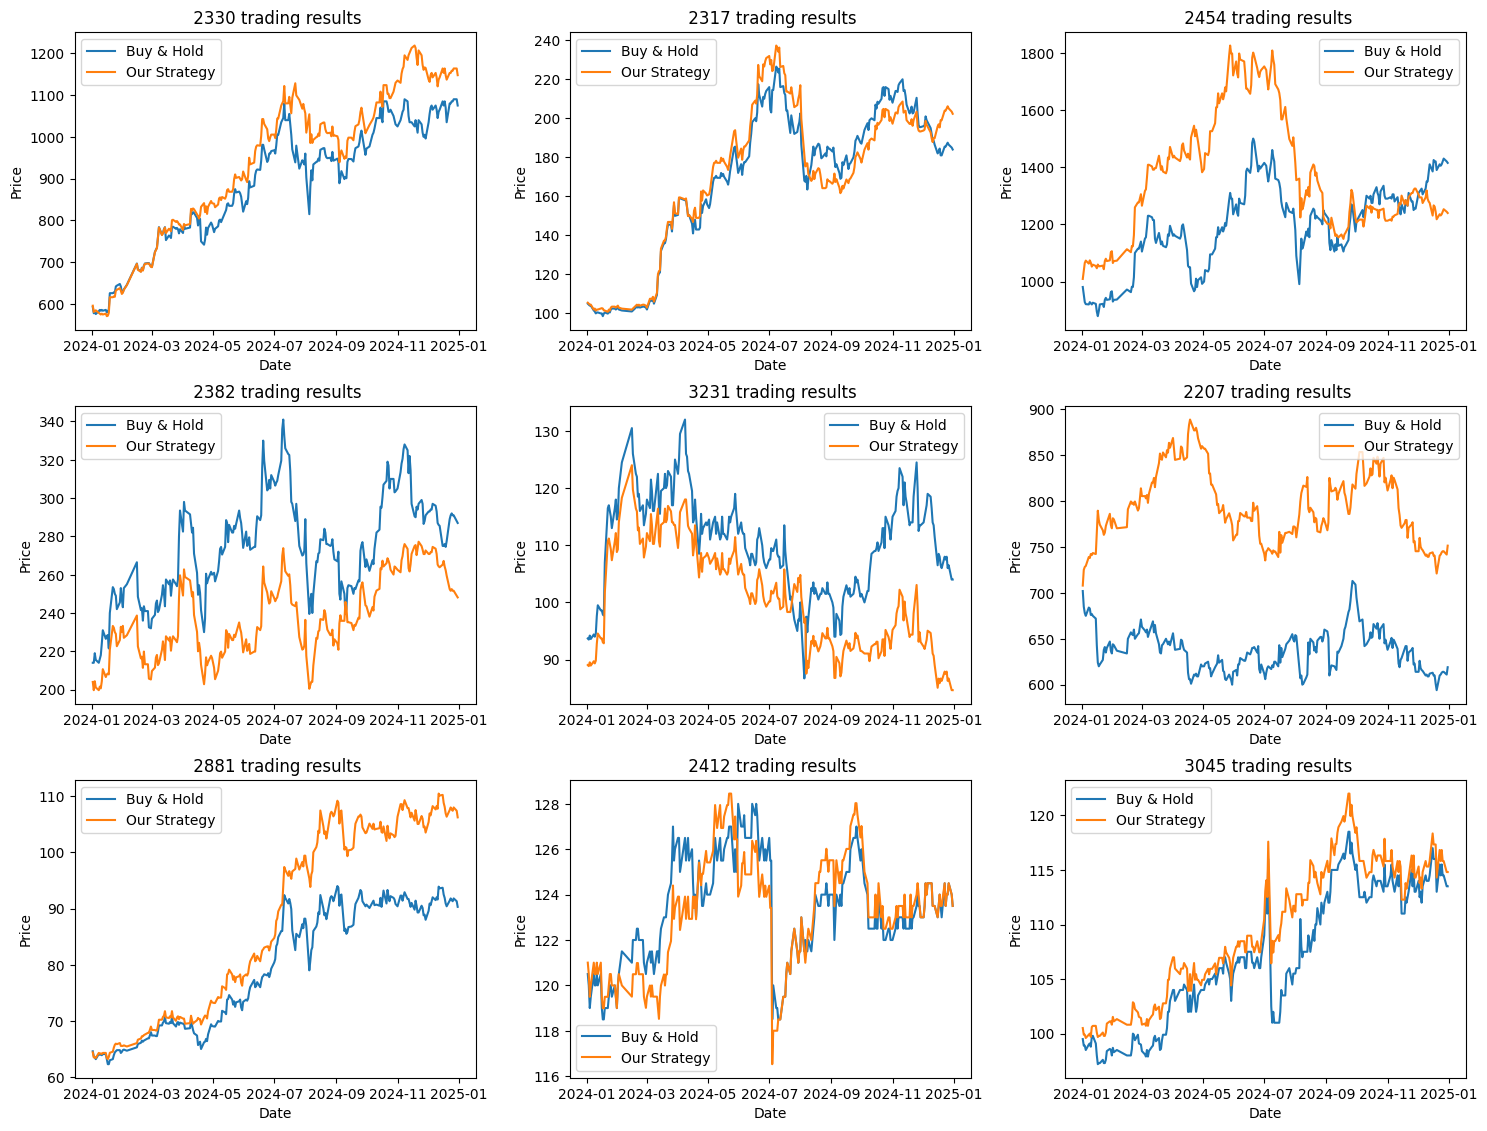

,accuracy,precision,ev,precision_ev,win B&H
第1次,48.37%,50.88%,0.00848,0.011622,0.67
總和,48.37%,50.88%,0.00848,0.011622,0.67


In [15]:
from usable_on_reason import UsableReasonON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableReasonON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            mode = 1    # 0:acc 1:ev
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            
            # plot fig
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
        
        # # show stock results
        # stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        # stock_avg.index = [stock[0]]
        # display(stock_avg.loc[:, selected_columns])
        
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])